Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64


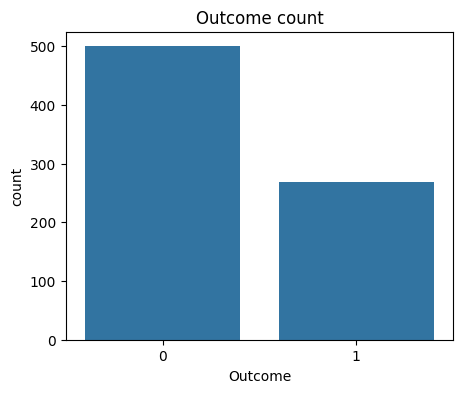

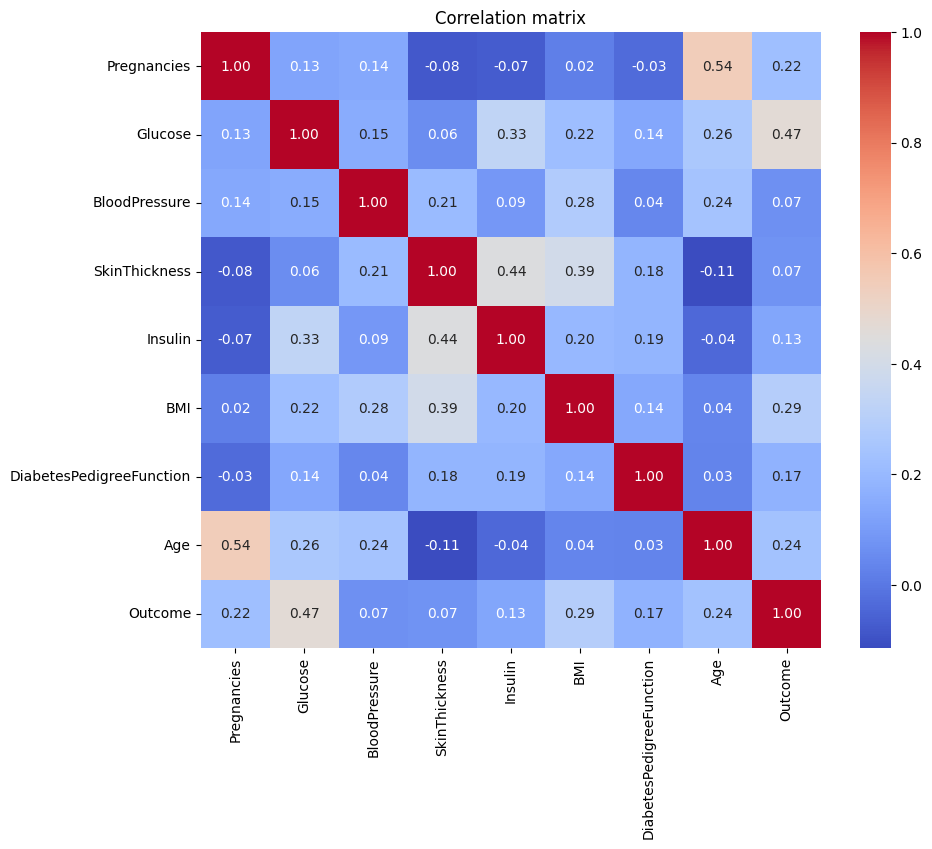

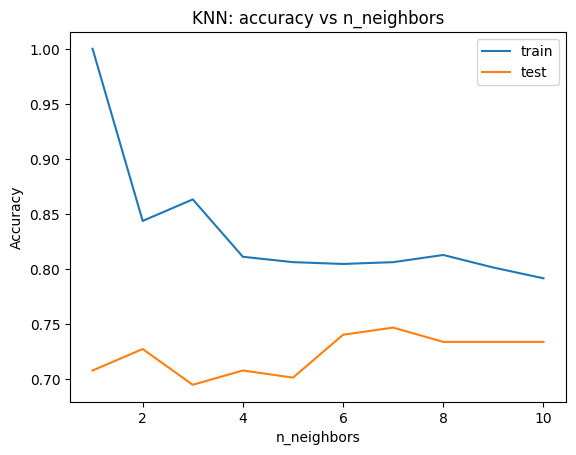

Decision Tree - train acc: 0.767, test acc: 0.695
Decision Tree feature importances: [0.         0.64256308 0.         0.         0.01856819 0.20109353
 0.         0.13777521]
RandomForest - train acc: 1.000, test acc: 0.747


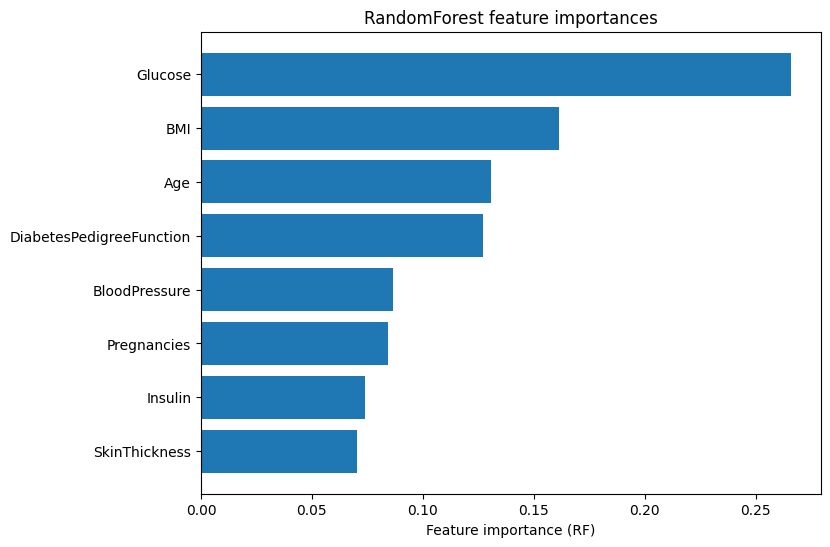

MLP - train acc: 0.762, test acc: 0.688

Cross-validated scores (5-fold stratified):
RandomForest: ROC-AUC mean=0.825, std=0.022
MLP: ROC-AUC mean=0.784, std=0.035
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best MLP params (grid search): {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate_init': 0.01}
Best MLP CV roc-auc: 0.8270873515024458

Test set evaluation (best_mlp):
Accuracy: 0.7532467532467533
ROC AUC: 0.8335185185185184

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



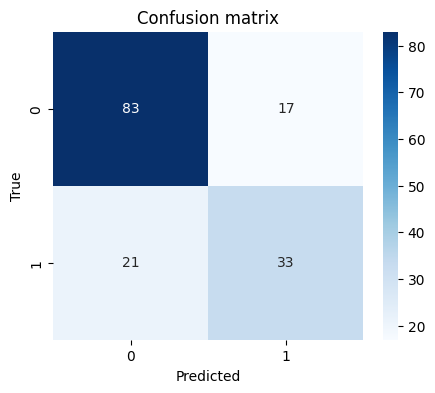

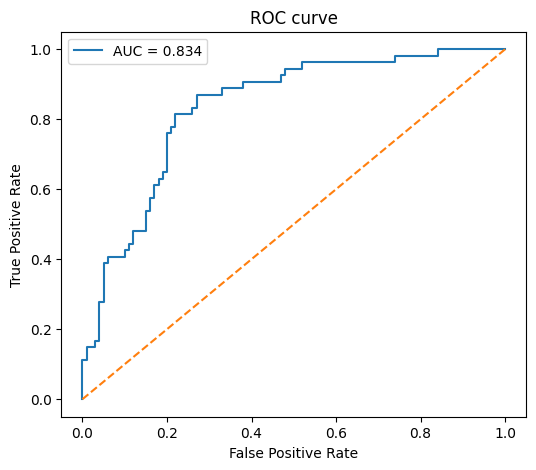

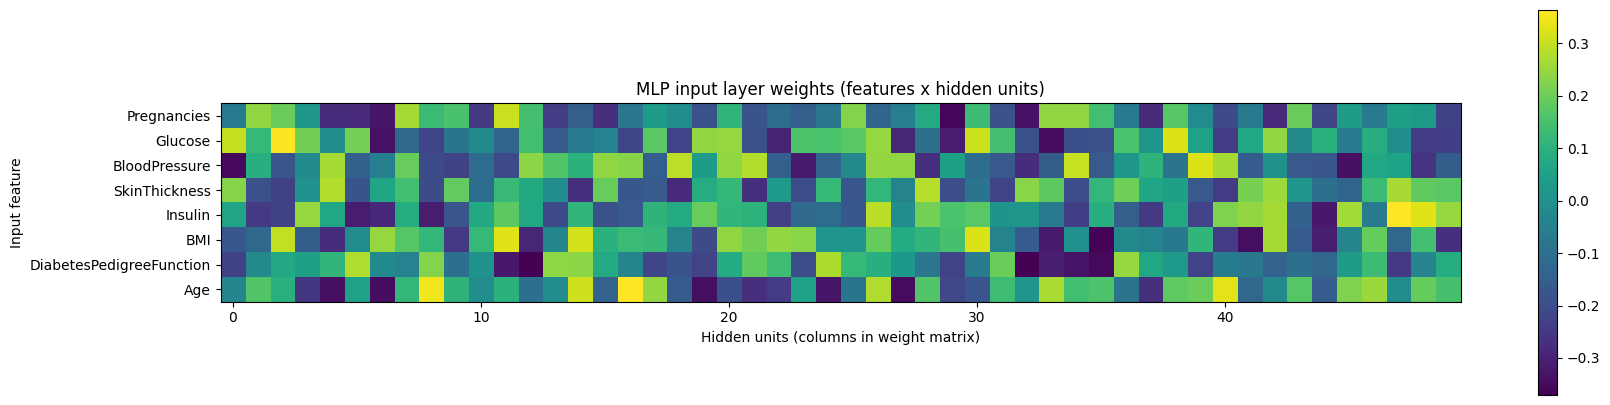

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

diabetes = pd.read_csv('diabetes.csv')

# features excluding the target
diabetes_features = [c for c in diabetes.columns if c != 'Outcome']

print("Columns:", diabetes.columns.tolist())
print("Shape:", diabetes.shape)
print(diabetes.head())

# EDA
print("\nOutcome counts:")
print(diabetes['Outcome'].value_counts())

import seaborn as sns
plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=diabetes)
plt.title("Outcome count")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(diabetes.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# Train / Test split
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
X = diabetes[diabetes_features]
y = diabetes['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Preprocessing (scaler) and utility imports
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib

scaler = StandardScaler()

# Baseline KNN (as you had) but using a pipeline and show accuracies over k
from sklearn.neighbors import KNeighborsClassifier
train_acc = []
test_acc = []
neighbors_settings = range(1, 11)
for k in neighbors_settings:
    pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    pipe_knn.fit(X_train, y_train)
    train_acc.append(pipe_knn.score(X_train, y_train))
    test_acc.append(pipe_knn.score(X_test, y_test))

plt.plot(list(neighbors_settings), train_acc, label='train')
plt.plot(list(neighbors_settings), test_acc, label='test')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.title('KNN: accuracy vs n_neighbors')
plt.show()

# Decision Tree & Random Forest baseline 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree - train acc: {:.3f}, test acc: {:.3f}".format(dt.score(X_train, y_train), dt.score(X_test, y_test)))
print("Decision Tree feature importances:", dt.feature_importances_)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('rf', rf)])
rf_pipeline.fit(X_train, y_train)
print("RandomForest - train acc: {:.3f}, test acc: {:.3f}".format(rf_pipeline.score(X_train, y_train), rf_pipeline.score(X_test, y_test)))

# Feature importances from RF
importances = rf_pipeline.named_steps['rf'].feature_importances_
idx_sorted = np.argsort(importances)
plt.figure(figsize=(8,6))
plt.barh(range(len(importances)), importances[idx_sorted], align='center')
plt.yticks(range(len(importances)), np.array(diabetes_features)[idx_sorted])
plt.xlabel("Feature importance (RF)")
plt.title("RandomForest feature importances")
plt.show()

#Improved MLP approach (fixing scaling bug + avoid convergence warning)
from sklearn.neural_network import MLPClassifier

# IMPORTANT: Use scaler.fit_transform on train and scaler.transform on test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# MLP with early stopping to avoid convergence warning
mlp = MLPClassifier(
    hidden_layer_sizes=(50, ),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)
print("MLP - train acc: {:.3f}, test acc: {:.3f}".format(mlp.score(X_train_scaled, y_train), mlp.score(X_test_scaled, y_test)))

# Evaluate best model candidates using cross validation
print("\nCross-validated scores (5-fold stratified):")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, estimator in [
    ("RandomForest", Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=200, random_state=42))])),
    ("MLP", Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(hidden_layer_sizes=(50,), early_stopping=True, max_iter=1000, random_state=42))]))
]:
    scores = cross_val_score(estimator, X, y, cv=skf, scoring='roc_auc')
    print(f"{name}: ROC-AUC mean={scores.mean():.3f}, std={scores.std():.3f}")

# Hyperparameter tuning example: GridSearch for MLP
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50,50)],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01]
}

pipe = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))])
gs = GridSearchCV(pipe, param_grid_mlp, cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1)
gs.fit(X, y)
print("Best MLP params (grid search):", gs.best_params_)
print("Best MLP CV roc-auc:", gs.best_score_)

# Use the best estimator found:
best_mlp = gs.best_estimator_

#Evaluate on test set
y_pred = best_mlp.predict(X_test)
y_proba = best_mlp.predict_proba(X_test)[:,1]

print("\nTest set evaluation (best_mlp):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()

# Visualize MLP input layer weights
coefs0 = best_mlp.named_steps['mlp'].coefs_[0]
plt.figure(figsize=(20, 5))
plt.imshow(coefs0, interpolation='none')
plt.yticks(range(len(diabetes_features)), diabetes_features)
plt.xlabel("Hidden units (columns in weight matrix)")
plt.ylabel("Input feature")
plt.colorbar()
plt.title("MLP input layer weights (features x hidden units)")
plt.show()